In [1]:
# --- Cell 1: imports ---
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
# --- Cell 2: path to NPZ (edit) ---
npz_path = Path(r"C:\Users\1\Downloads\LNOF_J30_4D_aligned.npz")  # <-- поменяй путь
npz_path.exists(), npz_path


(True, WindowsPath('C:/Users/1/Downloads/LNOF_J30_4D_aligned.npz'))

In [3]:
# --- Cell 3: load + list variables ---
data = np.load(npz_path, allow_pickle=True)

keys = list(data.keys())
print(f"Loaded: {npz_path.name}")
print(f"Variables ({len(keys)}):")
for i, k in enumerate(keys):
    arr = data[k]
    shape = getattr(arr, "shape", None)
    dtype = getattr(arr, "dtype", None)
    print(f"{i:>3}. {k:<40} shape={shape} dtype={dtype}")


Loaded: LNOF_J30_4D_aligned.npz
Variables (22):
  0. Calcium                                  shape=(163, 107203) dtype=float32
  1. Reconstructions                          shape=(163, 107203) dtype=float32
  2. x                                        shape=(107203,) dtype=float64
  3. y                                        shape=(107203,) dtype=float64
  4. speed                                    shape=(107203,) dtype=float64
  5. bodydirection                            shape=(107203,) dtype=float64
  6. headdirection                            shape=(107203,) dtype=float64
  7. rest                                     shape=(107203,) dtype=float64
  8. walk                                     shape=(107203,) dtype=float64
  9. locomotion                               shape=(107203,) dtype=float64
 10. freezing                                 shape=(107203,) dtype=float64
 11. rear                                     shape=(107203,) dtype=float64
 12. corners                    

ModuleNotFoundError: No module named 'numpy._core'

In [4]:
# --- Cell 4: quick inspector for selected variables ---
def describe_var(name, max_print=10):
    if name not in data:
        print(f"[!] '{name}' not found.")
        return
    arr = data[name]
    print(f"\n=== {name} ===")
    print("type:", type(arr))
    if hasattr(arr, "shape"):
        print("shape:", arr.shape, "dtype:", arr.dtype)
        # try flatten preview
        flat = np.ravel(arr)
        n = min(len(flat), max_print)
        print(f"first {n} values:", flat[:n])
        if np.issubdtype(arr.dtype, np.number) and flat.size > 0:
            print("min/max:", np.nanmin(flat), np.nanmax(flat))
    else:
        print("value:", arr)

# Example: describe first 3 variables
for k in keys[:3]:
    describe_var(k)



=== Calcium ===
type: <class 'numpy.ndarray'>
shape: (163, 107203) dtype: float32
first 10 values: [-7.4309664 -7.4309664 -7.4309664 -7.4309664 -7.4309664 -7.4309664
 -7.4309664 -7.4309664 -7.4309664 -7.4309664]
min/max: -25.9594 757.3362

=== Reconstructions ===
type: <class 'numpy.ndarray'>
shape: (163, 107203) dtype: float32
first 10 values: [2.2943343e-16 2.4377304e-16 2.4377304e-16 2.7245222e-16 3.1547099e-16
 2.7245222e-16 2.5811262e-16 2.5811262e-16 2.2943343e-16 2.7245222e-16]
min/max: 0.0 1.0

=== x ===
type: <class 'numpy.ndarray'>
shape: (107203,) dtype: float64
first 10 values: [12.34741053 12.33634546 12.22772033 12.20979951 12.17334448 12.09651895
 11.99362653 11.89449825 11.88698196 11.9589799 ]
min/max: 7.835906132112205 51.61765267442606


In [5]:
# --- Cell 5: choose variables to plot ---
print("Available variables:")
for i, k in enumerate(keys):
    print(f"{i:>3}: {k}")

choice = input("\nChoose variables by indices (comma-separated), e.g. 0,2,5: ").strip()
idx = [int(x) for x in choice.split(",") if x.strip() != ""]
selected = [keys[i] for i in idx]

print("\nSelected:")
for k in selected:
    describe_var(k, max_print=5)


Available variables:
  0: Calcium
  1: Reconstructions
  2: x
  3: y
  4: speed
  5: bodydirection
  6: headdirection
  7: rest
  8: walk
  9: locomotion
 10: freezing
 11: rear
 12: corners
 13: walls
 14: center
 15: object1
 16: object2
 17: object3
 18: object4
 19: objects
 20: _metadata
 21: _sync_info

Choose variables by indices (comma-separated), e.g. 0,2,5: 2,3

Selected:

=== x ===
type: <class 'numpy.ndarray'>
shape: (107203,) dtype: float64
first 5 values: [12.34741053 12.33634546 12.22772033 12.20979951 12.17334448]
min/max: 7.835906132112205 51.61765267442606

=== y ===
type: <class 'numpy.ndarray'>
shape: (107203,) dtype: float64
first 5 values: [32.45367229 32.43017253 32.14894128 32.07137135 31.9138917 ]
min/max: 9.679508749705036 54.641226257254715


In [6]:
# --- Cell 6: build x-axis (optional) ---
# Если в npz уже есть переменная времени/оси X (например 't', 'time', 'x'), укажи её здесь.
# Иначе будет использован индекс 0..N-1.

x_name = input("\nOptional: name of x-axis variable (press Enter to use index): ").strip()

x = None
if x_name:
    if x_name not in data:
        print(f"[!] '{x_name}' not found, using index instead.")
    else:
        x = np.array(data[x_name]).squeeze()
        print(f"Using x from '{x_name}', shape={x.shape}, dtype={x.dtype}")



Optional: name of x-axis variable (press Enter to use index): 


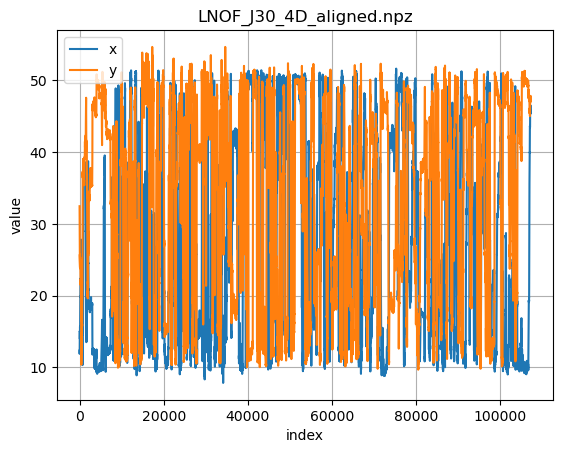

In [8]:
# --- Cell 7: plotting f(x) / time series ---
def to_1d(y):
    y = np.array(y)
    y = np.squeeze(y)
    # если вдруг многомерный массив (например, (N, K)), берём первый столбец как дефолт
    if y.ndim > 1:
        print(f"[i] '{y.shape}' is not 1D; taking y[:, 0] by default")
        y = y[0:1000, 0]
    return y

plt.figure()
for name in selected:
    y = to_1d(data[name])

    if x is None:
        xx = np.arange(len(y))
    else:
        # на всякий случай выравниваем длины
        n = min(len(x), len(y))
        xx, y = x[:n], y[:n]

    plt.plot(xx, y, label=name)

plt.xlabel(x_name if x_name else "index")
plt.ylabel("value")
plt.title(npz_path.name)
plt.legend()
plt.grid(True)
plt.show()


Calcium: (163, 107203) float32
Selected: (3, 107203)


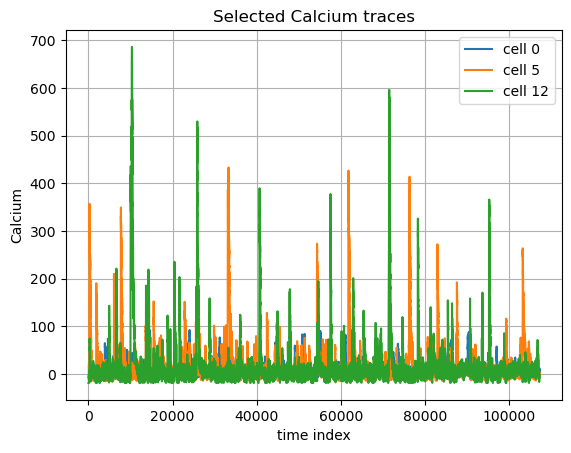

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# === path to your npz ===
npz_path = Path(r"C:\Users\1\Downloads\LNOF_J30_4D_aligned.npz")  # <-- поменяй путь

# === load Calcium and take selected rows ===
with np.load(npz_path, allow_pickle=True) as d:
    Calcium = d["Calcium"]  # shape: (n_cells, n_timepoints)

print("Calcium:", Calcium.shape, Calcium.dtype)

# Выбери номера строк (клеток) здесь (0-based индексация!)
rows = [0, 5, 12]  # <-- поменяй под себя

# Вытаскиваем только нужные строки
Calcium_sel = Calcium[rows, :]  # shape: (len(rows), n_timepoints)
print("Selected:", Calcium_sel.shape)

# Быстрый просмотр (каждая строка отдельной линией)
plt.figure()
t = np.arange(Calcium_sel.shape[1])
for i, r in enumerate(rows):
    plt.plot(t, Calcium_sel[i], label=f"cell {r}")
plt.xlabel("time index")
plt.ylabel("Calcium")
plt.title("Selected Calcium traces")
plt.legend()
plt.grid(True)
plt.show()
